In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/WA_Fn-UseC_-Telco-Customer-Churn_CLEANED.xlsx")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#check existing features
print("Columns:")
for col in df.columns:
    print(col)

Columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [ ]:
#customer value
df["CustomerValue"] = df["tenure"] * df["MonthlyCharges"]

df[[
    "customerID",
    "tenure",
    "MonthlyCharges",
    "CustomerValue"
]].head(10)

,customerID,tenure,MonthlyCharges,CustomerValue
0,7590-VHVEG,1,29.85,29.85
1,5575-GNVDE,34,56.95,1936.30
2,3668-QPYBK,2,53.85,107.70
3,7795-CFOCW,45,42.30,1903.50
4,9237-HQITU,2,70.70,141.40
5,9305-CDSKC,8,99.65,797.20
6,1452-KIOVK,22,89.10,1960.20
7,6713-OKOMC,10,29.75,297.50
8,7892-POOKP,28,104.80,2934.40
9,6388-TABGU,62,56.15,3481.30


In [ ]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    df[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

print(df["TotalServices"].head())

0    1
1    3
2    3
3    3
4    1
Name: TotalServices, dtype: int64


In [ ]:
#average per service
df["AvgChargePerService"] = np.where(
    df["TotalServices"] > 0,
    df["MonthlyCharges"] / df["TotalServices"],
    df["MonthlyCharges"]
)

df[[
    "MonthlyCharges",
    "TotalServices",
    "AvgChargePerService"
]].head(10)

,MonthlyCharges,TotalServices,AvgChargePerService
0,29.85,1,29.850000
1,56.95,3,18.983333
2,53.85,3,17.950000
3,42.30,3,14.100000
4,70.70,1,70.700000
5,99.65,5,19.930000
6,89.10,4,22.275000
7,29.75,1,29.750000
8,104.80,6,17.466667
9,56.15,3,18.716667


In [ ]:
#low tenure flag
df["LowTenureFlag"] = np.where(
    df["tenure"] <= 12,
    1,
    0
)

print(df["LowTenureFlag"].value_counts())

LowTenureFlag
0    4857
1    2186
Name: count, dtype: int64


In [ ]:
#high monthly charge flag
median_charge = df["MonthlyCharges"].median()

df["HighMonthlyCharge"] = np.where(
    df["MonthlyCharges"] > median_charge,
    1,
    0
)

print("Median Monthly Charge:", median_charge)
print(df["HighMonthlyCharge"].value_counts())

Median Monthly Charge: 70.35
HighMonthlyCharge
0    3528
1    3515
Name: count, dtype: int64


In [ ]:
#long term customer flag
df["LongTermCustomer"] = np.where(
    df["tenure"] >= 48,
    1,
    0
)

print(df["LongTermCustomer"].value_counts())

LongTermCustomer
0    4740
1    2303
Name: count, dtype: int64


In [ ]:
#multile service flag
df["MultipleServicesFlag"] = np.where(
    df["TotalServices"] >= 3,
    1,
    0
)

print(df["MultipleServicesFlag"].value_counts())

MultipleServicesFlag
1    4074
0    2969
Name: count, dtype: int64


In [ ]:
#contract stability score
contract_score = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}

df["ContractStabilityScore"] = df["Contract"].map(contract_score)

df[
    ["Contract", "ContractStabilityScore"]
].head(10)

,Contract,ContractStabilityScore
0,Month-to-month,0
1,One year,1
2,Month-to-month,0
3,One year,1
4,Month-to-month,0
5,Month-to-month,0
6,Month-to-month,0
7,Month-to-month,0
8,Month-to-month,0
9,One year,1


In [ ]:
#automatic payment flag
automatic_methods = [
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

df["AutomaticPaymentFlag"] = np.where(
    df["PaymentMethod"].isin(automatic_methods),
    1,
    0
)

print(df["AutomaticPaymentFlag"].value_counts())

AutomaticPaymentFlag
0    3977
1    3066
Name: count, dtype: int64


In [ ]:
#churn into numerical flag
df["ChurnFlag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df["ChurnFlag"].value_counts())

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Create missing Day 1 features

# Average monthly revenue
df["AverageMonthlyRevenue"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

# Difference between monthly charge and average revenue
df["ChargeDifference"] = (
    df["MonthlyCharges"] - df["AverageMonthlyRevenue"]
)

# Charge ratio
df["ChargeRatio"] = np.where(
    df["AverageMonthlyRevenue"] > 0,
    df["MonthlyCharges"] / df["AverageMonthlyRevenue"],
    1
)

print("Day 1 features created successfully!")

Day 1 features created successfully!


In [ ]:
#new features against churn
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AverageMonthlyRevenue",
    "ChargeDifference",
    "ChargeRatio",
    "TotalServices",
    "CustomerValue",
    "AvgChargePerService",
    "LowTenureFlag",
    "HighMonthlyCharge",
    "LongTermCustomer",
    "MultipleServicesFlag",
    "ContractStabilityScore",
    "AutomaticPaymentFlag"
]

correlation = df[features + ["ChurnFlag"]].corr()

churn_correlation = (
    correlation["ChurnFlag"]
    .sort_values(ascending=False)
)

print(churn_correlation)

ChurnFlag                 1.000000
LowTenureFlag             0.317580
AvgChargePerService       0.312886
HighMonthlyCharge         0.195663
MonthlyCharges            0.193356
AverageMonthlyRevenue     0.192531
ChargeRatio               0.011679
MultipleServicesFlag      0.002529
ChargeDifference          0.002159
TotalServices            -0.067264
CustomerValue            -0.198514
TotalCharges             -0.199484
AutomaticPaymentFlag     -0.209902
LongTermCustomer         -0.266758
tenure                   -0.352229
ContractStabilityScore   -0.396713
Name: ChurnFlag, dtype: float64


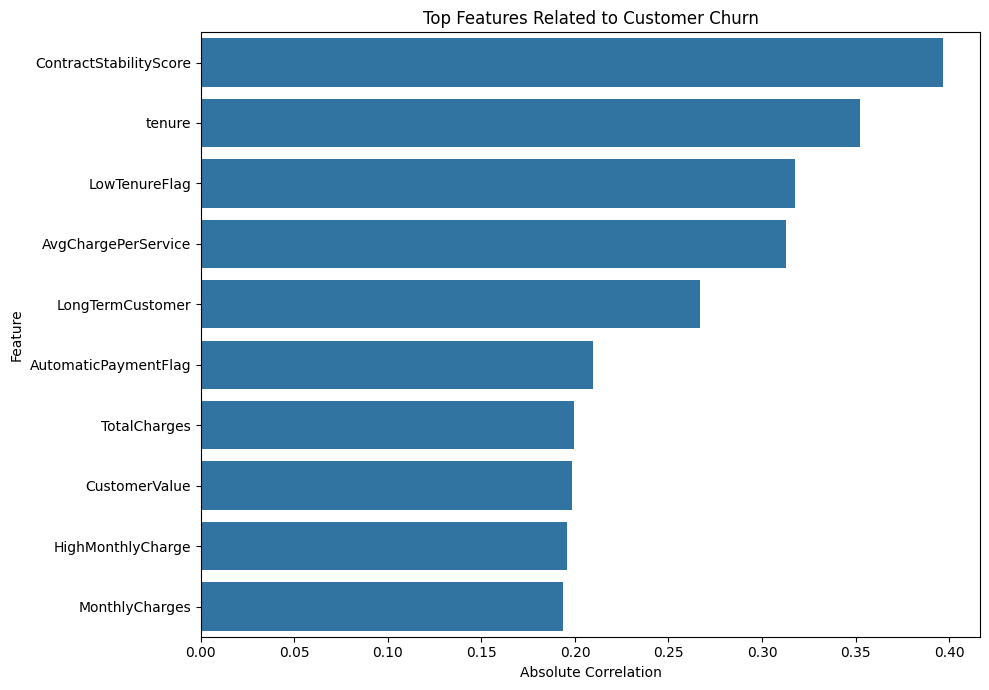

In [ ]:
#colleration visualization
plt.figure(figsize=(10, 7))

sns.barplot(
    x=churn_correlation.drop("ChurnFlag").abs().sort_values(ascending=False).head(10).values,
    y=churn_correlation.drop("ChurnFlag").abs().sort_values(ascending=False).head(10).index
)

plt.title("Top Features Related to Customer Churn")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
#feature distribution
df[
    [
        "CustomerValue",
        "AvgChargePerService",
        "MonthlyCharges",
        "TotalCharges",
        "tenure",
        "TotalServices"
    ]
].describe()

,CustomerValue,AvgChargePerService,MonthlyCharges,TotalCharges,tenure,TotalServices
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000
mean,2279.581350,22.509972,64.761692,2283.300441,32.371149,3.362914
std,2264.729447,11.576218,30.090047,2266.771362,24.559481,2.062031
min,0.000000,10.416667,18.250000,18.800000,0.000000,0.000000
25%,394.000000,15.700000,35.500000,401.450000,9.000000,1.000000
50%,1393.600000,19.750000,70.350000,1397.475000,29.000000,3.000000
75%,3786.100000,24.525000,89.850000,3794.737500,55.000000,5.000000
max,8550.000000,72.250000,118.750000,8684.800000,72.000000,8.000000


In [ ]:
#categerical fucntion
print("Contract vs Churn")
print(
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
)

print("\nPayment Method vs Churn")
print(
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    ) * 100
)

Contract vs Churn
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

Payment Method vs Churn
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [ ]:
#missing values
print("Total missing values:", df.isnull().sum().sum())

missing = df.isnull().sum()
print(missing[missing > 0])

Total missing values: 11
TotalCharges    11
dtype: int64


In [ ]:
#final feature list
new_features = [
    "CustomerValue",
    "AvgChargePerService",
    "LowTenureFlag",
    "HighMonthlyCharge",
    "LongTermCustomer",
    "MultipleServicesFlag",
    "ContractStabilityScore",
    "AutomaticPaymentFlag"
]

print("New Features Created:\n")

for feature in new_features:
    print("-", feature)

New Features Created:

- CustomerValue
- AvgChargePerService
- LowTenureFlag
- HighMonthlyCharge
- LongTermCustomer
- MultipleServicesFlag
- ContractStabilityScore
- AutomaticPaymentFlag


In [ ]:
df.to_excel(
    "/content/WA_Fn-UseC_-Telco-Customer-Churn_CLEANED.xlsx",
    index=False
)

print("✅ Shubham Day 2 dataset saved successfully!")

✅ Shubham Day 2 dataset saved successfully!


In [ ]:
print("Final Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nNumber of columns:", len(df.columns))

Final Shape: (7043, 34)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,LowTenureFlag,HighMonthlyCharge,LongTermCustomer,MultipleServicesFlag,ContractStabilityScore,AutomaticPaymentFlag,ChurnFlag,AverageMonthlyRevenue,ChargeDifference,ChargeRatio
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,1,0,0,0,0,0,0,29.850000,0.000000,1.000000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,0,0,0,1,1,0,0,55.573529,1.376471,1.024768
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,1,0,0,1,0,0,1,54.075000,-0.225000,0.995839
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,0,0,0,1,1,1,0,40.905556,1.394444,1.034089
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,1,0,0,0,0,1,75.825000,-5.125000,0.932410



Number of columns: 34
